# 1. Harris County Median Income Map

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('income_data.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3379,564,1767,477,785,379,0,21,...,89554,57312,"250,000+",***,90811,37795,83994,55270,-,**
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1475,198,325,113,277,111,49,60,...,58295,41148,-,**,44115,21129,43490,27101,56000,41680
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1932,214,556,149,200,199,20,28,...,"2,500-",***,76940,33304,56800,23197,55726,42532,113042,99817
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2375,483,1083,322,4,13,15,24,...,21408,1122,176584,105067,49953,35894,48386,26132,202938,125864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,145,56,27,24,75,50,0,21,...,-,**,-,**,101339,54166,101339,54166,-,**
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,5,7,5,7,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**


In [4]:
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import os
os.listdir()

['ACSST5Y2024.S0802-Data.csv',
 'ACSST5Y2024.S1903-Data.csv',
 'ACSST5Y2024.S2201-Data.csv',
 'harris_county_heat_maps.ipynb',
 'income_data.csv',
 'snap_data.csv',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx',
 'vehicle_data.csv']

In [5]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [6]:
harris = gdf[gdf["COUNTYFP"] == "201"]

In [7]:
merged = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [8]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

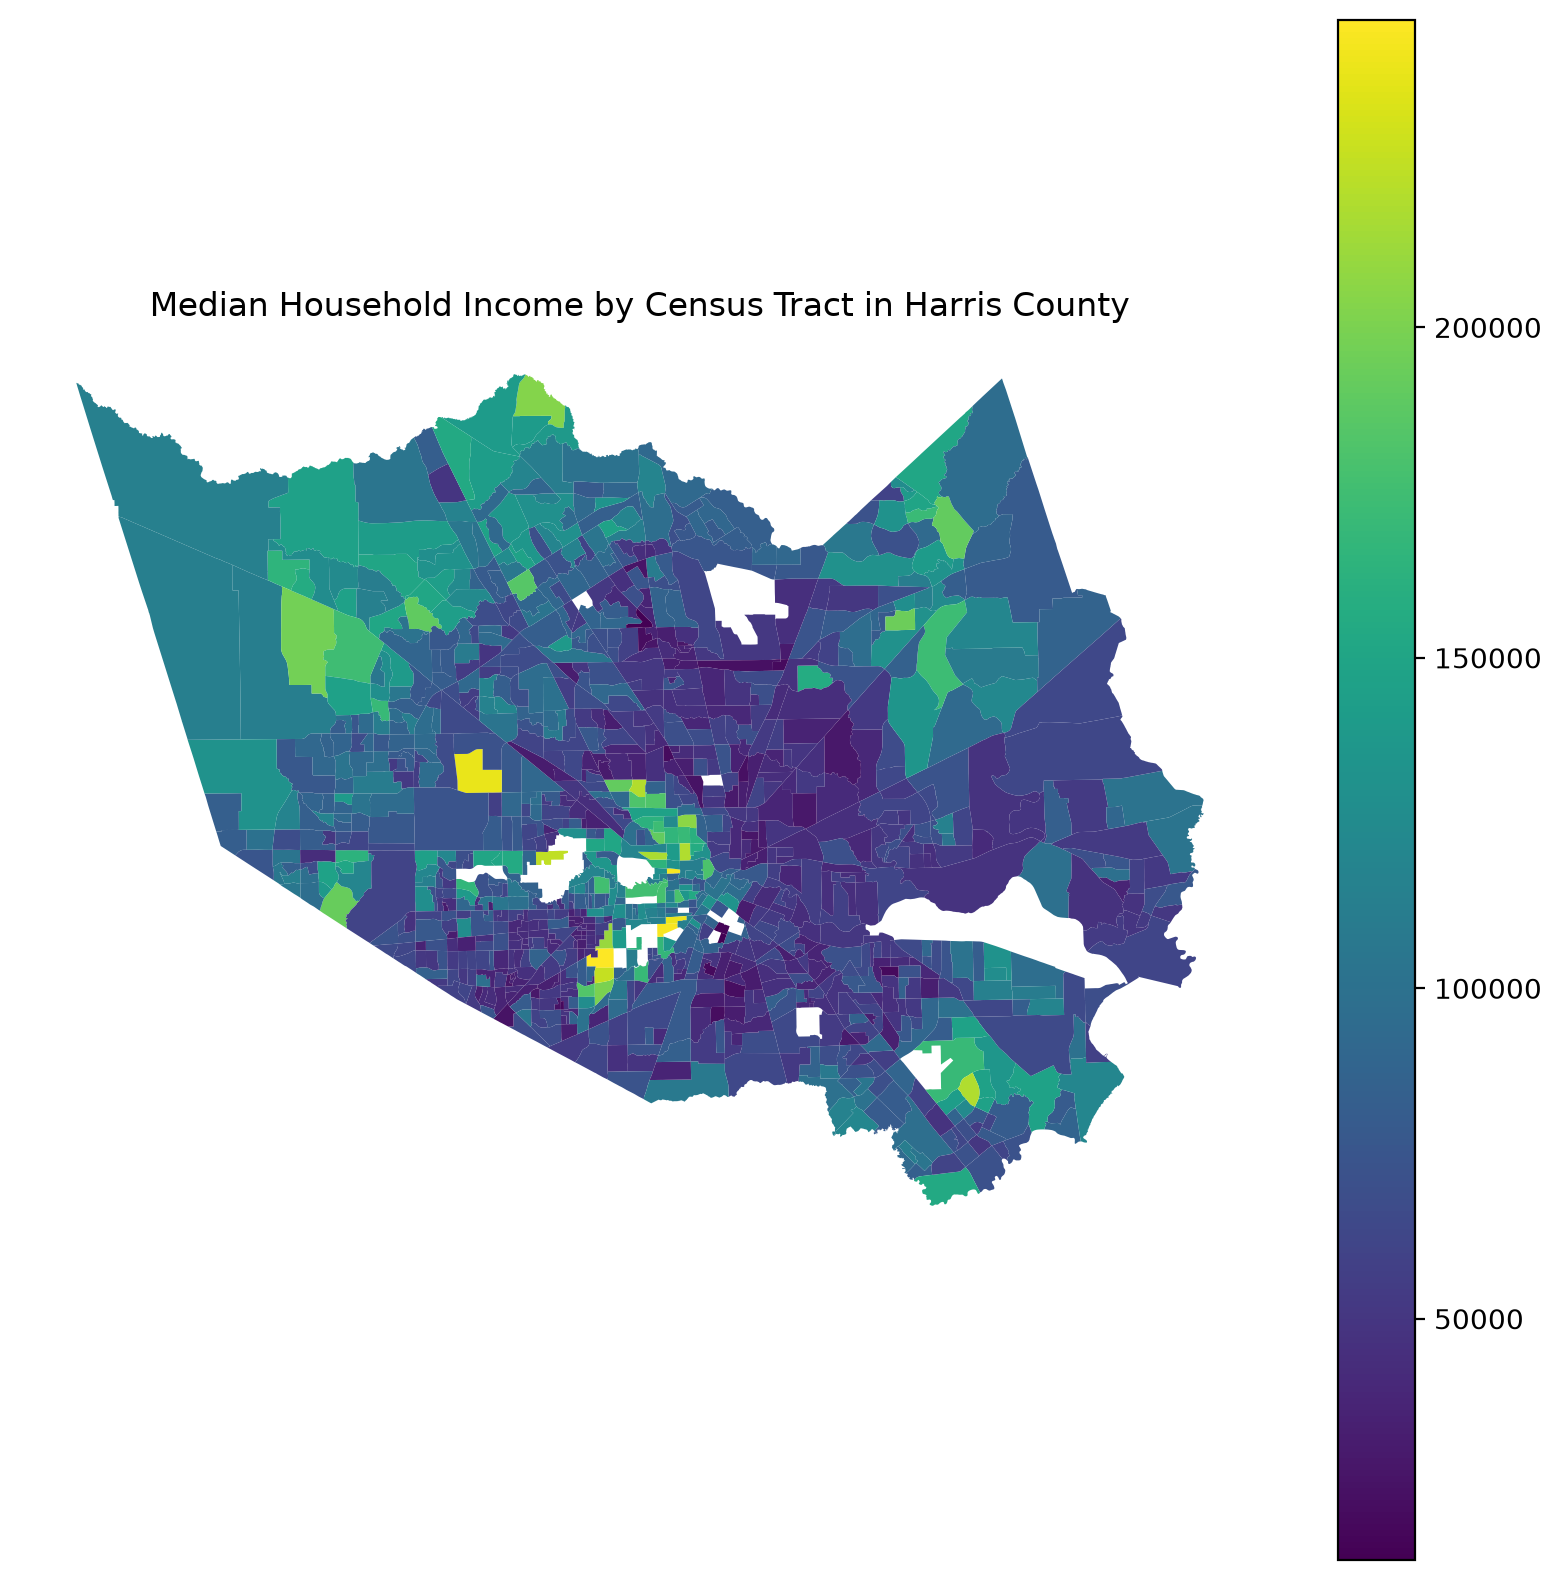

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Harris County")
plt.axis("off")
plt.show()

# 2. Mobility Map (No Vehicle Acces)

In [10]:
df = pd.read_csv('vehicle_data.csv')
df

C:\Users\saraz\AppData\Local\Temp\ipykernel_27316\3869483300.py:1: DtypeWarning: Columns (0: S0802_C01_001E, 1: S0802_C01_001M, 2: S0802_C01_028E, 3: S0802_C01_028M, 4: S0802_C01_038E, 5: S0802_C01_038M, 6: S0802_C01_042E, 7: S0802_C01_042M, 8: S0802_C01_070E, 9: S0802_C01_070M, 10: S0802_C01_091E, 11: S0802_C01_091M, 12: S0802_C02_001E, 13: S0802_C02_001M, 14: S0802_C02_028E, 15: S0802_C02_028M, 16: S0802_C02_038E, 17: S0802_C02_038M, 18: S0802_C02_042E, 19: S0802_C02_042M, 20: S0802_C02_070E, 21: S0802_C02_070M, 22: S0802_C02_091E, 23: S0802_C02_091M, 24: S0802_C03_001E, 25: S0802_C03_001M, 26: S0802_C03_028E, 27: S0802_C03_028M, 28: S0802_C03_038E, 29: S0802_C03_038M, 30: S0802_C03_042E, 31: S0802_C03_042M, 32: S0802_C03_070E, 33: S0802_C03_070M, 34: S0802_C03_091E, 35: S0802_C03_091M, 36: S0802_C04_001E, 37: S0802_C04_001M, 38: S0802_C04_028E, 39: S0802_C04_028M, 40: S0802_C04_038E, 41: S0802_C04_038M, 42: S0802_C04_042E, 43: S0802_C04_042M, 44: S0802_C04_070E, 45: S0802_C04_070M, 

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3680,677,0.2,0.3,9,6.3,69.5,10.5,...,0,5,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1876,334,6.6,4.7,16.4,7.7,39.3,9.9,...,10.5,12.1,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1821,314,0,2.7,10.2,6.2,42.1,10.1,...,28.6,24.6,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2838,522,0.4,0.7,0.1,0.8,51.2,12,...,7.7,7.8,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,128,58,0,31.2,0,31.2,68,27,...,0,100,(X),(X),(X),(X),(X),(X),(X),(X)
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,745,159,24.8,10.4,67.8,10.7,7.4,8.4,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,1188,298,25.8,13,65.2,12,8.9,7.1,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)


In [11]:
merged_2 = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [12]:
merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

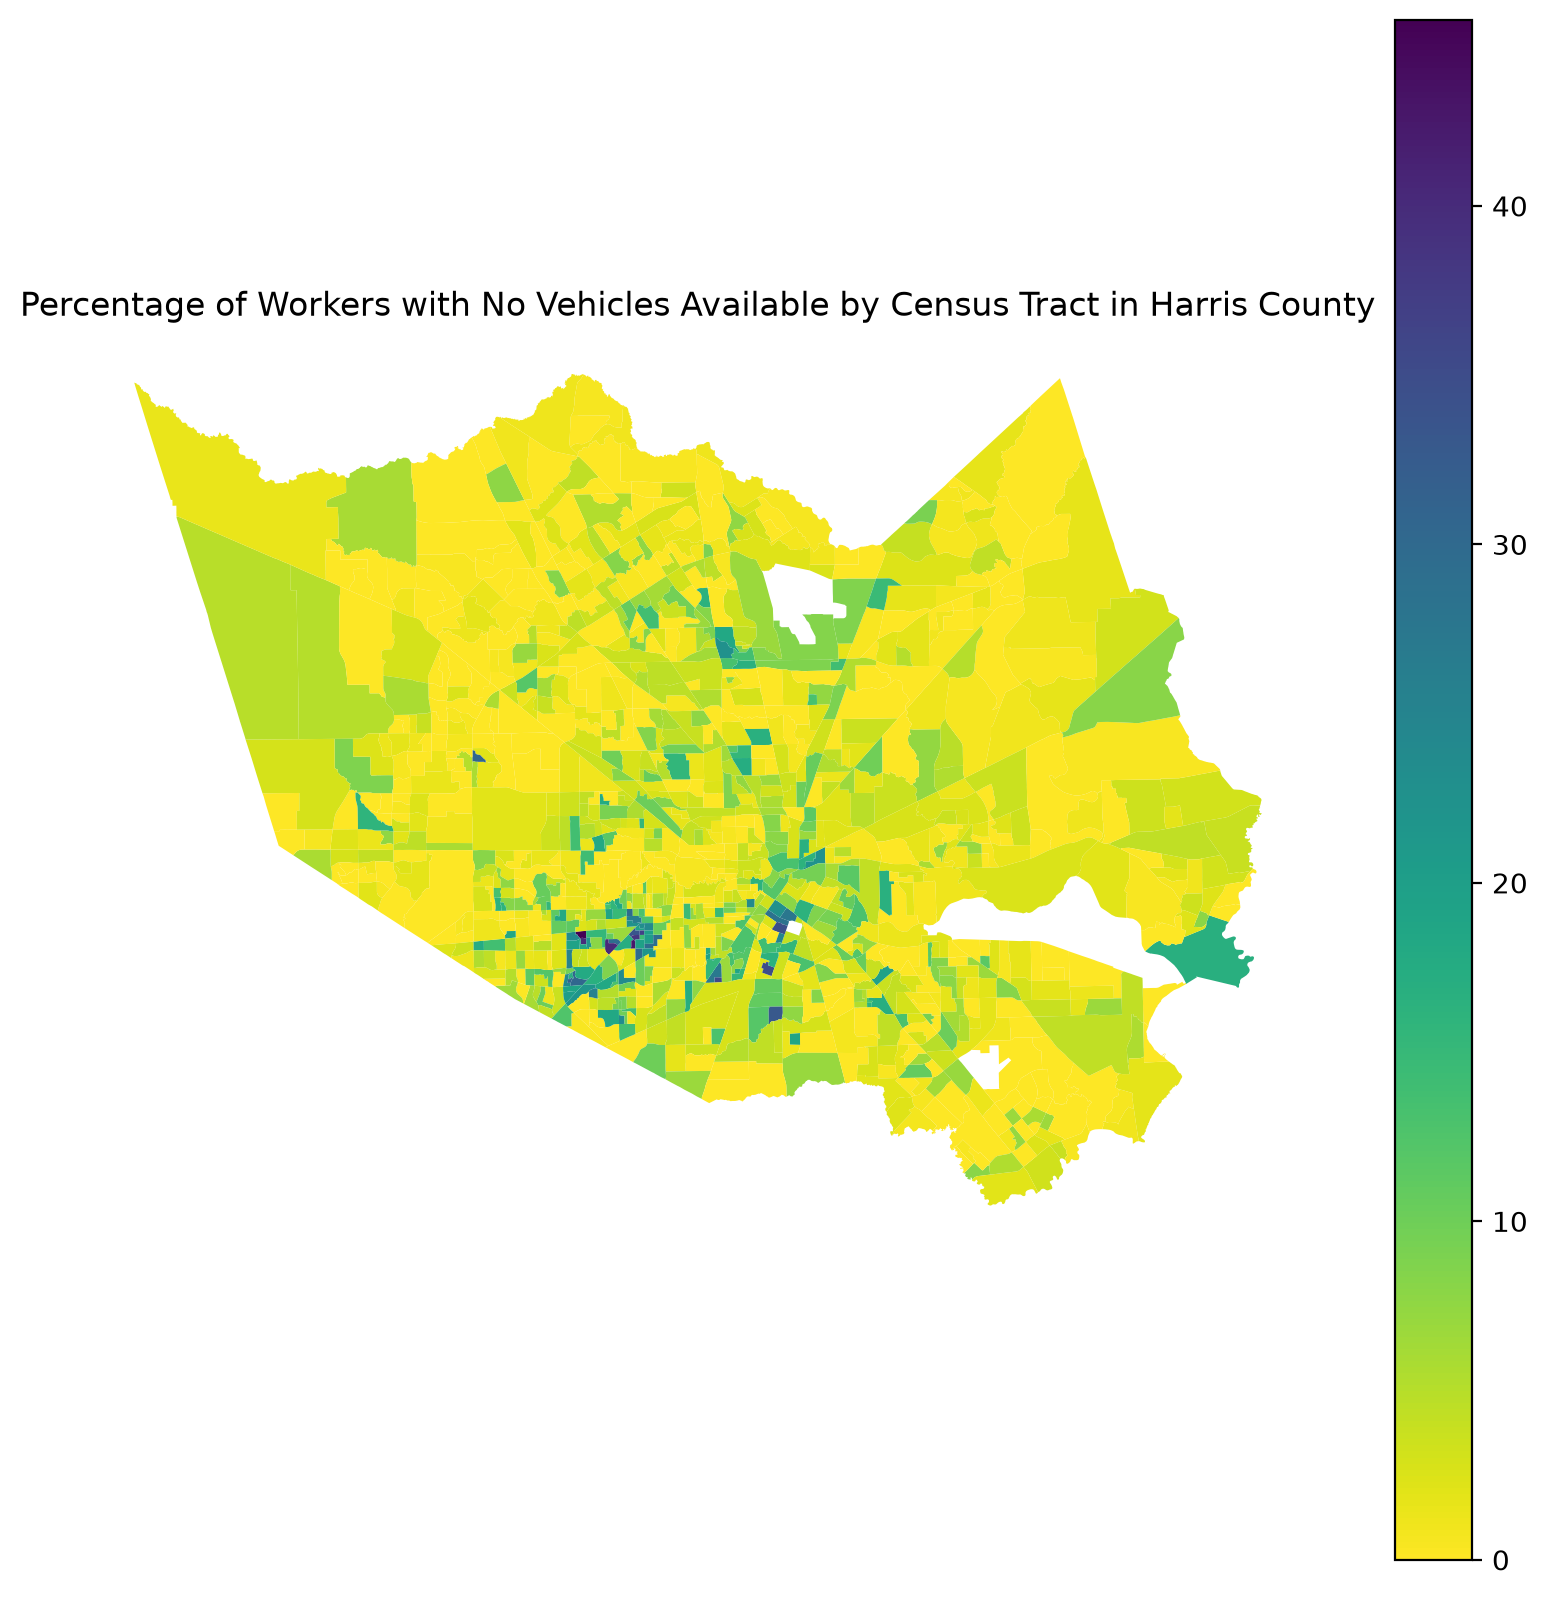

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Harris County")
plt.axis("off")
plt.show()

# 3. SNAP Map

In [14]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3379,564,181,120,3198,558,489,265,...,(X),(X),(X),(X),0,8.6,55.7,23.4,44.3,23.4
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1475,198,682,200,793,177,488,121,...,(X),(X),(X),(X),6.8,6.1,22.6,9.5,70.7,10.6
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1932,214,1129,258,803,209,646,214,...,(X),(X),(X),(X),9.2,7.9,46.2,14.5,44.6,13.9
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2375,483,1065,481,1310,247,860,267,...,(X),(X),(X),(X),13.4,13.6,52.8,24,33.8,19.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,145,56,8,6,137,57,5,8,...,(X),(X),(X),(X),0,84.4,73.7,53.4,26.3,53.4
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,5,7,0,15,5,7,5,7,...,(X),(X),(X),(X),0,100,0,100,100,100
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**


In [15]:
merged_3 = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

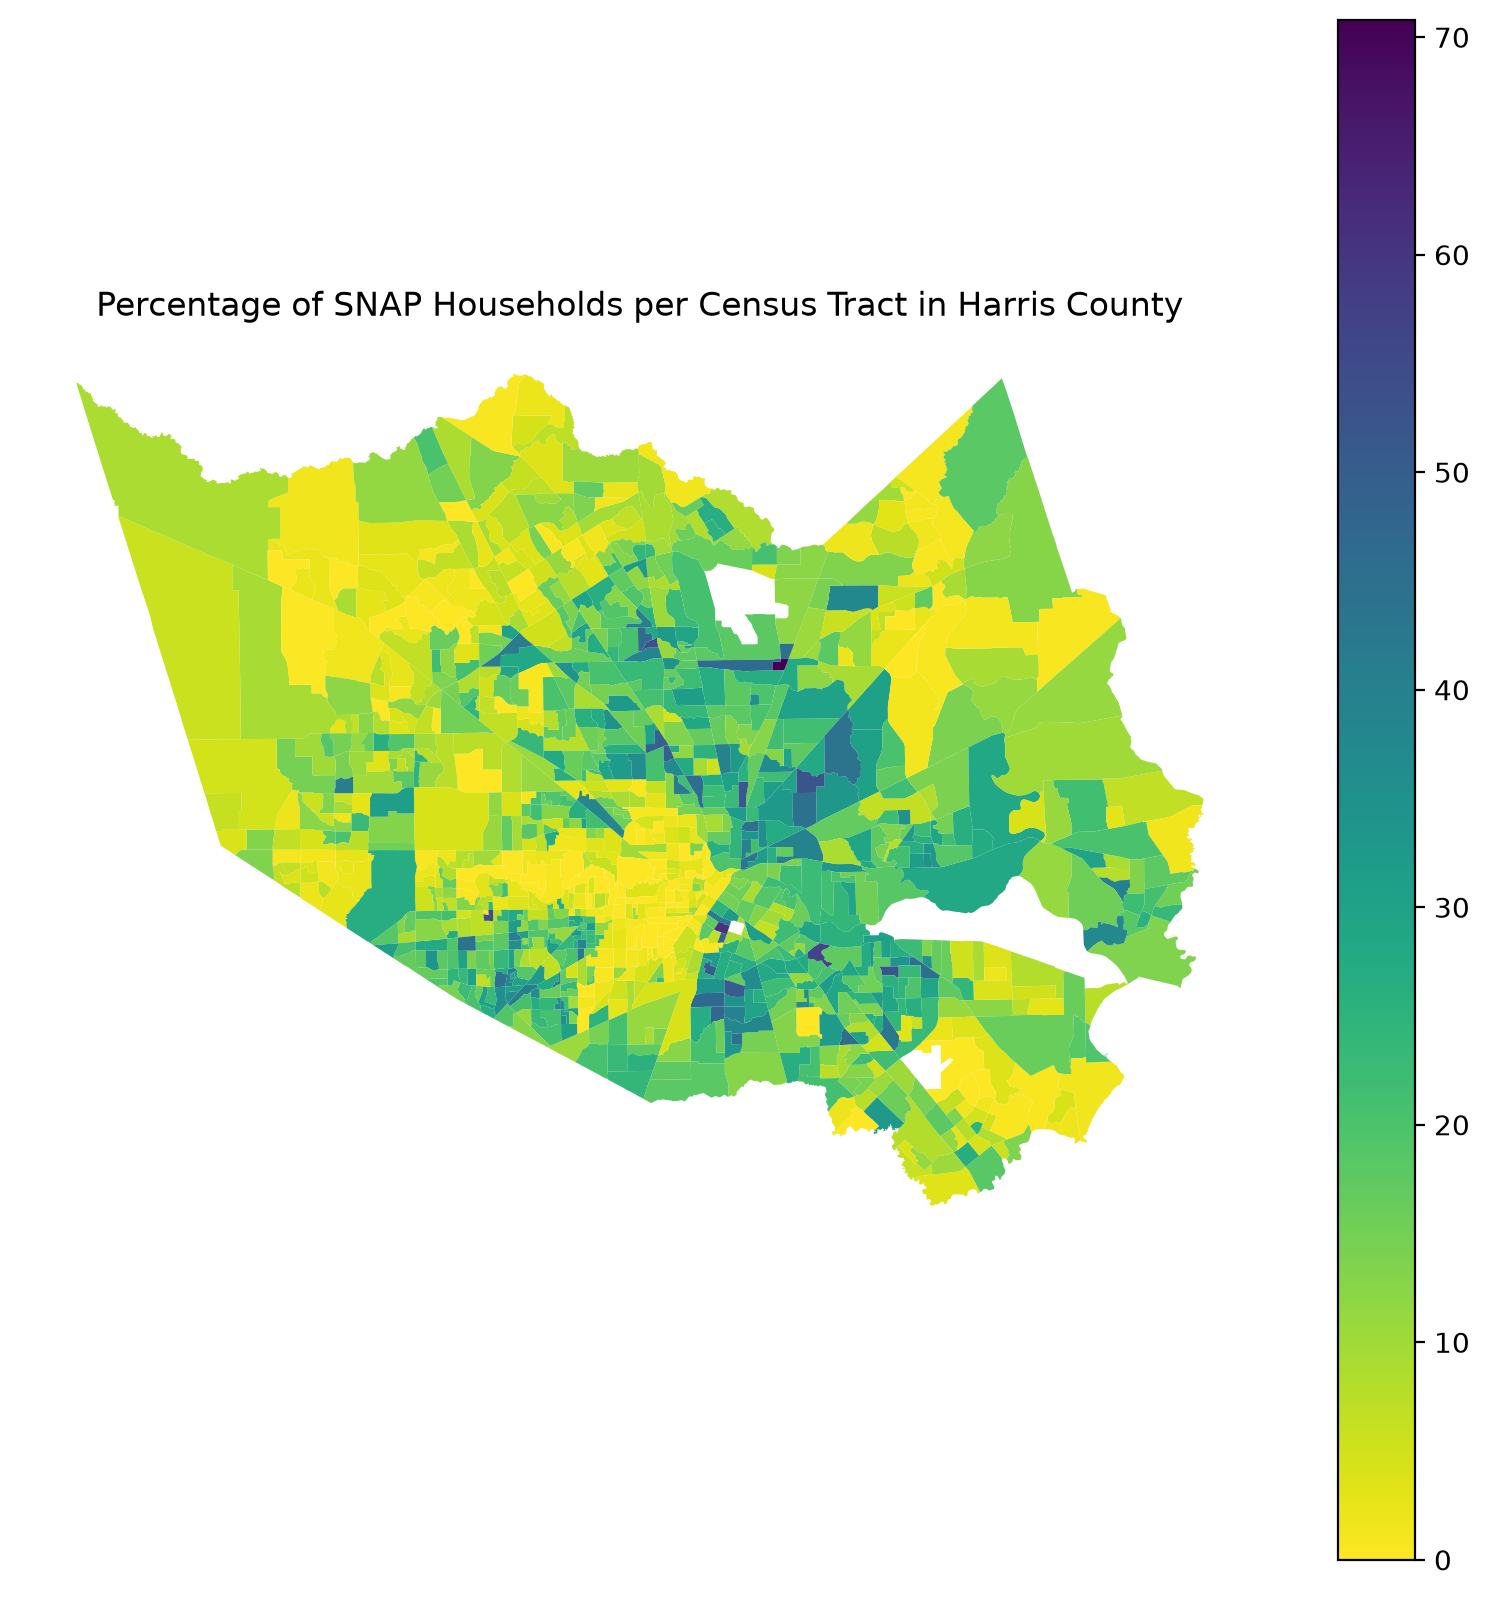

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_3.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households per Census Tract in Harris County")
plt.axis("off")
plt.show()

# 4. Low Income According to State Median Income

In [17]:
#State Median Income
#make sure column is numeric
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

#binary variable
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*79721
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

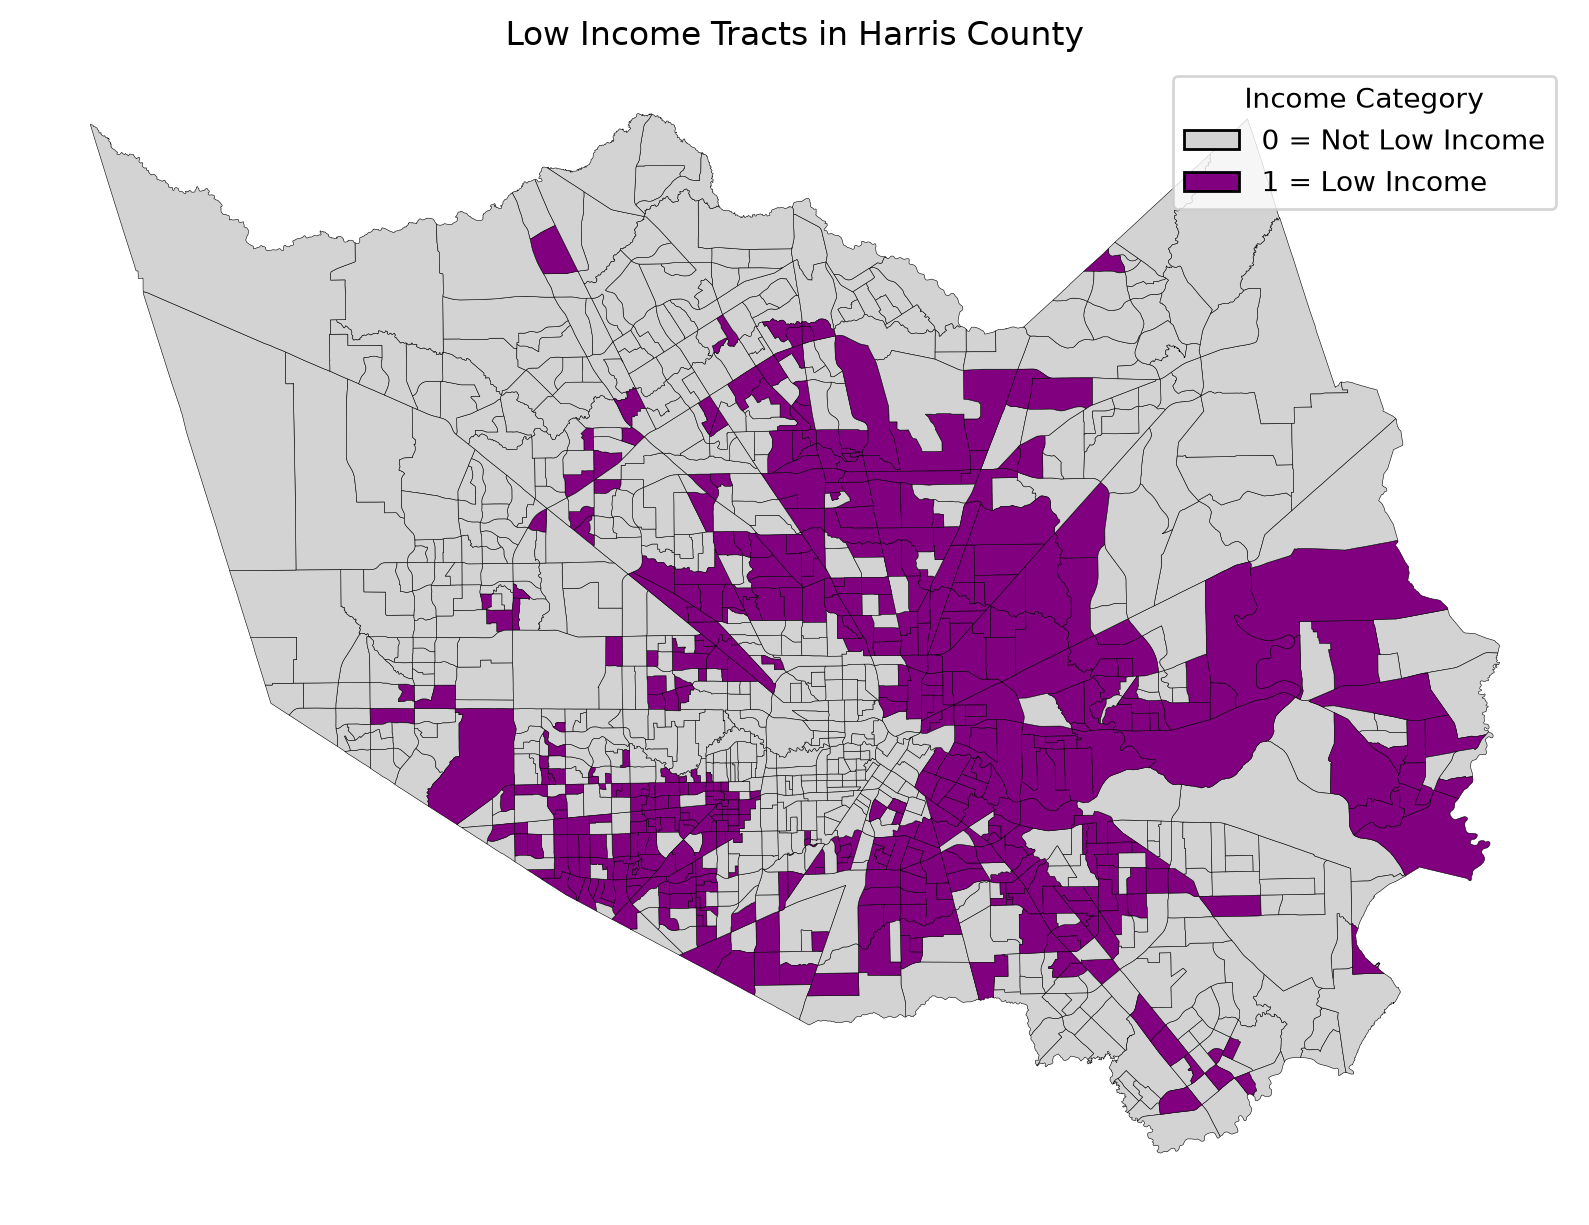

In [ ]:
#low income according to state median income plot
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch 

cmap = ListedColormap(["lightgrey","Purple"])

fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column="binary_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Low Income"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Low Income")
]

ax.legend(handles=legend_elements, title="Income Category")

plt.title("Low Income Tracts in Harris County")
plt.axis("off")
plt.show()

# 5. Metropolitan Area Median Family Income

This map displays for each census tract that is in a metropolitan area that has a median income less than 80% of the metropolitan area's median income. Harris County is located in the Houston-Pasadena Metropolitan Area. The median income for this area for 2024 is $81, 417.

In [19]:
df_2= pd.read_csv('harris_metropolitan.csv')

C:\Users\saraz\AppData\Local\Temp\ipykernel_27316\3917526299.py:1: DtypeWarning: Columns (0: S0802_C01_001E, 1: S0802_C01_001M, 2: S0802_C01_028E, 3: S0802_C01_028M, 4: S0802_C01_038E, 5: S0802_C01_038M, 6: S0802_C01_042E, 7: S0802_C01_042M, 8: S0802_C01_070E, 9: S0802_C01_070M, 10: S0802_C01_091E, 11: S0802_C01_091M, 12: S0802_C02_001E, 13: S0802_C02_001M, 14: S0802_C02_028E, 15: S0802_C02_028M, 16: S0802_C02_038E, 17: S0802_C02_038M, 18: S0802_C02_042E, 19: S0802_C02_042M, 20: S0802_C02_070E, 21: S0802_C02_070M, 22: S0802_C02_091E, 23: S0802_C02_091M, 24: S0802_C03_001E, 25: S0802_C03_001M, 26: S0802_C03_028E, 27: S0802_C03_028M, 28: S0802_C03_038E, 29: S0802_C03_038M, 30: S0802_C03_042E, 31: S0802_C03_042M, 32: S0802_C03_070E, 33: S0802_C03_070M, 34: S0802_C03_091E, 35: S0802_C03_091M, 36: S0802_C04_001E, 37: S0802_C04_001M, 38: S0802_C04_028E, 39: S0802_C04_028M, 40: S0802_C04_038E, 41: S0802_C04_038M, 42: S0802_C04_042E, 43: S0802_C04_042M, 44: S0802_C04_070E, 45: S0802_C04_070M, 

In [ ]:
gdf = gpd.read_file("tl_2024_48_tract.shp")
harris = gdf[gdf["COUNTYFP"] == "201"]

In [25]:
income = pd.read_csv("income_data.csv")
income.head()

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3379,564,1767,477,785,379,0,21,...,89554,57312,"250,000+",***,90811,37795,83994,55270,-,**
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1475,198,325,113,277,111,49,60,...,58295,41148,-,**,44115,21129,43490,27101,56000,41680
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1932,214,556,149,200,199,20,28,...,"2,500-",***,76940,33304,56800,23197,55726,42532,113042,99817
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2375,483,1083,322,4,13,15,24,...,21408,1122,176584,105067,49953,35894,48386,26132,202938,125864


In [26]:
income["GEOID"] = income["GEO_ID"].str[-11:]

In [28]:
merged_2 = harris.merge(income, on="GEOID", how="left")

In [29]:
merged_2["S1903_C03_001E"] = pd.to_numeric(
    merged_2["S1903_C03_001E"],
    errors="coerce"
)

merged_2["binary_income_2"] = (
    merged_2["S1903_C03_001E"] < 0.8 * 81417
).astype(int)

In [23]:
[col for col in merged_2.columns if "S1903" in col]

[]

# 6. Low- Income Tracts

In [32]:
df_poverty = pd.read_csv('df_poverty.csv')
df_poverty

,GEO_ID,NAME,S1701_C01_001E,S1701_C01_001M,S1701_C01_002E,S1701_C01_002M,S1701_C01_003E,S1701_C01_003M,S1701_C01_004E,S1701_C01_004M,...,S1701_C03_058E,S1701_C03_058M,S1701_C03_059E,S1701_C03_059M,S1701_C03_060E,S1701_C03_060M,S1701_C03_061E,S1701_C03_061M,S1701_C03_062E,S1701_C03_062M
0,Geography,Geographic Area Name,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...
1,310M700US26420,"Houston-Pasadena-The Woodlands, TX Metro Area",7704439,4934,1957180,5313,496047,3900,1461133,5064,...,(X),(X),4.2,0.7,34.8,2.5,53.1,1.7,14.3,0.5


In [33]:
#merging SHP file
merged_3 = harris.merge(
    df_poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [ ]:
#merging SHP file
merged_3 = harris.merge(
    df_poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [36]:
#make sure values numeric
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [37]:
merged_3["binary_poverty"] = (
    merged_3["S1701_C03_001E"] >= 20.0
).astype(int)

# 7. Merging All Datasets

In [38]:
#make copy of binary columns in first dataframe 
combined = merged.copy()

combined["binary_income_2"] = merged_2["binary_income_2"].values
combined["binary_poverty"] = merged_3["binary_poverty"].values

#final USDA criterion
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

#plot
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Low Income Tracts in Harris County'}>

In [39]:
#each condition as an or statement 
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

In [40]:
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Low Income Tracts in Harris County'}>

# 8. Importing SNAP Data

In [41]:
# filter by state and county (Harris County, TX)

df = pd.read_csv("snap_retailer_location_data.csv")
harris_snap = df[(df["State"]== "TX") & (df["County"]=="HARRIS")]

print(harris_snap.shape)
print(harris_snap["Store_Type"].value_counts())

(3439, 17)
Store_Type
Convenience Store      1933
Other                   672
Grocery Store           297
Super Store             246
Supermarket             223
Specialty Store          50
Farmers and Markets      18
Name: count, dtype: int64


In [42]:
# want to exclude Dollar General, Dollar Tree, CVS Pharmacy, CVS, Family Dollar,  Walgreens

excluded_others=["Dollar", "CVS", "Walgreen", "Walgrens", "Pharmacy"]

new_harris_data = harris_snap[(harris_snap["Store_Type"] == "Other") 
    & ~harris_snap["Store_Name"].str.contains("|".join(excluded_others), case=False, na=False)].copy()
print(new_harris_data.shape)
print(new_harris_data["Store_Name"].unique())

(96, 17)
<StringArray>
[                  'CARNICERIA AGUASCALIENTES',
                          'MY HOA FOOD MARKET',
               'Casa Del Pueblo Meat Market 3',
                     'PANCHO'S MEAT MARKET #3',
       'ALIEF AFRICAN FOOD MEAT & FISH MARKET',
                        'PANCHO'S MEAT MARKET',
                         'Golden Seafood Inc.',
                'La Michoacana Meat Market 21',
                        'G & J African Market',
      'Affordable Mobile Groceries 2819281084',
                  'Hung Dong Food Market 249 ',
     'C.K.C African Foods Store And Groceries',
               'MATAMOROS MEAT MARKET #3 INC.',
                      'Cypress Indian Grocery',
                              'LA MORELIANA 2',
                                 'K &t Stores',
                    'Pancho's Meat Market 4 4',
                  'LA VERACRUZANA MEAT MARKET',
                             'PARIVAR GROCERS',
                           'Tierra Caliente 2',
                 

In [43]:
# sorting the stores, I looked online on google maps photos and reivews and their website, if i could find any evidence they sold produce I kept it. 
# Ethnic grocery stores were the hardest to classify, lack of media presence made it hard to clearly tell if there was fresh produce being sold. Lmmm Houston 70 Ltd. 70 standed for La Michoacana Meat Market. 

kept_harris_others=["Braum", "La Michoacana", "Pancho's Meat Market", "Vishala", "Casa Del Pueblo", "Lmmm Houston", "Siempre Grocery", "La Michoacana Supermarket", "ALIEF AFRICAN FOOD MEAT & FISH MARKET", "G & J African Market", "Hung Dong Food Market 249",
                   "C.K.C African Foods Store And Groceries", "MATAMOROS MEAT MARKET", "Cypress Indian Grocery", "LA MORELIANA 2", "LA VERACRUZANA MEAT MARKET", "PARIVAR GROCERS", "Farmer's Fresh Meat", "Dominion African Food Mart", 
                    "La Congolaise", "Wazobia Market", "Subhlaxmi Grocers", "Maru Food Store", "Variedades 5 Estrellas", "Onola African Imports", "Holyland Meat Market", "Freetown International Market", "Thang Hung Food Market",
                    " K.C. African  Food Store N/A", "Motherland African Food Market & Halal Meat", "Lmmm Houston", "Welcome Food Center", "Central African Market Llc", "Hisway African Grocery Store N/A", "Afrik Kalabash Market", 
                    "Finca Tres Robles Farm Store", "Savoy Supermarket", "Chepes Meat Market", "Ca Mau Foods Market","La Moreliana Meat Market","Hong Kong Food Market", "Sangam Supermarket", "Dashlogs African Market", "Viet Nam Food Market", "Casa Del Pueblo Meat Market",
                    "Healthy Babies", "Tirupati Balaji Grocers", "Siempre Grocery", "Mercadito Catracho", "Lmmm Houston 70 Ltd. 70", "Lmmm Houston 83 Ltd.", "Siempre Grocery 030", "Siempre Grocery 032"] 

discarded_harris_others=["Tortilleria Zacatecas" , "CARNICERIA AGUASCALIENTES" , "Golden Seafood Inc.", "Affordable Mobile Groceries 2819281084", "K &t Stores", "Tierra Caliente ", "Wingate Mobile Groceries",  
                         "Bags & Boxes Mobile Grocery", " Carniceria Prime Meat Market Llc", "Agege Farmers Market", "Tana Grocery Store 1", "Elite Mobile Grocery", "On The Go Grocery Supply",
                         " Monyroth Seafood Market", "Mr N Food Store 00001", "Bellaire Fresh Food And Snacks", "A&a Bakery Panaderia Y Pasterleria Llc", "El Bolillo Bakery", "El Castillo Commissaria", "B And B Mobile Grocery", 
                         "Droubi's Bakery & Deli Inc. ", "Golden Asian Market", "Neas Market & Salon N/A", "Bay Area Meat Market & Deli", "Devillier's Boudin Highlands", 
                        ]

In [44]:
# filter out stores that are not grocery stores
included = ["Super Store","Supermarket","Grocery Store", "Farmers and Markets"]

keywords_pattern = "|".join(kept_harris_others)

cleaned_snap_data = harris_snap[
    harris_snap["Store_Type"].isin(included) |
    harris_snap["Store_Name"].str.contains(keywords_pattern, case=False, na=False)
].copy()

print(cleaned_snap_data.shape)

(842, 17)


In [45]:
# remove columns that are not needed :"Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y"

final_cleaned_snap_data = cleaned_snap_data.drop(columns=["Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y", "Zip4"])

In [46]:
# Check for duplicate store names at the same address
dupes = final_cleaned_snap_data[cleaned_snap_data.duplicated(subset=["Store_Name", "Store_Street_Address"], keep=False)]
print(dupes[["Store_Name", "Store_Street_Address"]])

Empty DataFrame
Columns: [Store_Name, Store_Street_Address]
Index: []


In [47]:
# final csv file created
final_cleaned_snap_data.to_csv("cleaned_harris_snap_data.csv", index=False)
print(final_cleaned_snap_data.shape)
print(final_cleaned_snap_data[["Store_Name", "Latitude", "Longitude", "Store_Type"]].head())

(842, 11)
                                       Store_Name   Latitude  Longitude  \
146                        Joe V's Smart Shop 792  29.832573 -95.722534   
594                           Siempre Grocery 019  29.670755 -95.528809   
595                            HEB Food Store 759  30.068659 -95.251701   
895                Cypress Grocery And Halal Meat  29.945112 -95.676521   
1527  Kohinoor Indo/pak Grocery Halal Meat & Cafe  30.067778 -95.507751   

         Store_Type  
146     Supermarket  
594   Grocery Store  
595     Supermarket  
895   Grocery Store  
1527  Grocery Store  


In [48]:
%matplotlib inline

# read CSV
df = pd.read_csv("cleaned_harris_snap_data.csv")

# make sure longitude/latitude are numeric
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

# remove rows with missing coordinates
df = df.dropna(subset=["Longitude", "Latitude"])

# create GeoDataFrame
geo_df = gpd.GeoDataFrame(
    df[[
        "Store_Name",
        "Store_Street_Address",
        "City",
        "Zip_Code",
        "Store_Type",
        "Latitude",
        "Longitude"
    ]],
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

geo_df.head()

,Store_Name,Store_Street_Address,City,Zip_Code,Store_Type,Latitude,Longitude,geometry
0,Joe V's Smart Shop 792,4107 Fry RD.,Katy,77449,Supermarket,29.832573,-95.722534,POINT (-95.72253 29.83257)
1,Siempre Grocery 019,9922 S Gessner Rd,Houston,77071,Grocery Store,29.670755,-95.528809,POINT (-95.52881 29.67076)
2,HEB Food Store 759,19529 Northpark Dr,Kingwood,77339,Supermarket,30.068659,-95.251701,POINT (-95.2517 30.06866)
3,Cypress Grocery And Halal Meat,11700 Barker Cypress Rd,Houston,77433,Grocery Store,29.945112,-95.676521,POINT (-95.67652 29.94511)
4,Kohinoor Indo/pak Grocery Halal Meat & Cafe,20423 Kuykendahl Rd,Spring,77379,Grocery Store,30.067778,-95.507751,POINT (-95.50775 30.06778)


In [49]:
import os
print(os.listdir("."))

['.gitignore', 'ACSST5Y2024.S0802-Data.csv', 'ACSST5Y2024.S1903-Data.csv', 'ACSST5Y2024.S2201-Data.csv', 'cleaned_harris_snap_data.csv', 'clean_harris_snap_data.ipynb', 'df_poverty.csv', 'harris_county_heat_maps.ipynb', 'harris_metropolitan.csv', 'harris_snap_map.png', 'income_data.csv', 'mapping_harris_snap.ipynb', 'snap_data.csv', 'snap_retailer_location_data.csv', 'tl_2024_48_tract.cpg', 'tl_2024_48_tract.dbf', 'tl_2024_48_tract.prj', 'tl_2024_48_tract.shp', 'tl_2024_48_tract.shp.ea.iso.xml', 'tl_2024_48_tract.shp.iso.xml', 'tl_2024_48_tract.shx', 'vehicle_data.csv']


In [50]:
# make grocery store points from longitude and latitude
stores = gpd.GeoDataFrame(
    final_cleaned_snap_data,
    geometry=gpd.points_from_xy(
        final_cleaned_snap_data["Longitude"],
        final_cleaned_snap_data["Latitude"]
    ),
    crs="EPSG:4326"
)

# make sure tract map has a coordinate system
merged = merged.set_crs("EPSG:4269", allow_override=True)

# 3 convert both into meters for distance calculations
tracts_m = merged.to_crs("EPSG:3857")
stores_m = stores.to_crs("EPSG:3857")

# get tract centroids
tracts_m["centroid"] = tracts_m.geometry.centroid
centroids = tracts_m.set_geometry("centroid")

# find nearest grocery store to each tract centroid with join_nearest function
nearest = gpd.sjoin_nearest(
    centroids,
    stores_m[["Store_Name", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

# convert meters to miles
nearest["distance_miles"] = nearest["distance_meters"] / 1609.34

In [51]:
nearest = nearest.sort_values("distance_meters").drop_duplicates("GEOID")

low_access_map = merged.merge(
    nearest[["GEOID", "distance_miles"]],
    on="GEOID",
    how="left"
)

low_access_map["binary_low_access"] = (
    low_access_map["distance_miles"] > 1
).astype(int)

# 9. Low Access and Low Income Map

In [52]:
#merge two datasets
final_map = combined.merge(
    low_access_map[["GEOID","binary_low_access"]],
    on="GEOID",
    how="left"
)

In [53]:
#conditional AND statement food desert indicator (low income and low access)
final_map["food_desert"] = (
    (final_map["binary_low_income"] == 1) & 
    (final_map["binary_low_access"] == 1)
)

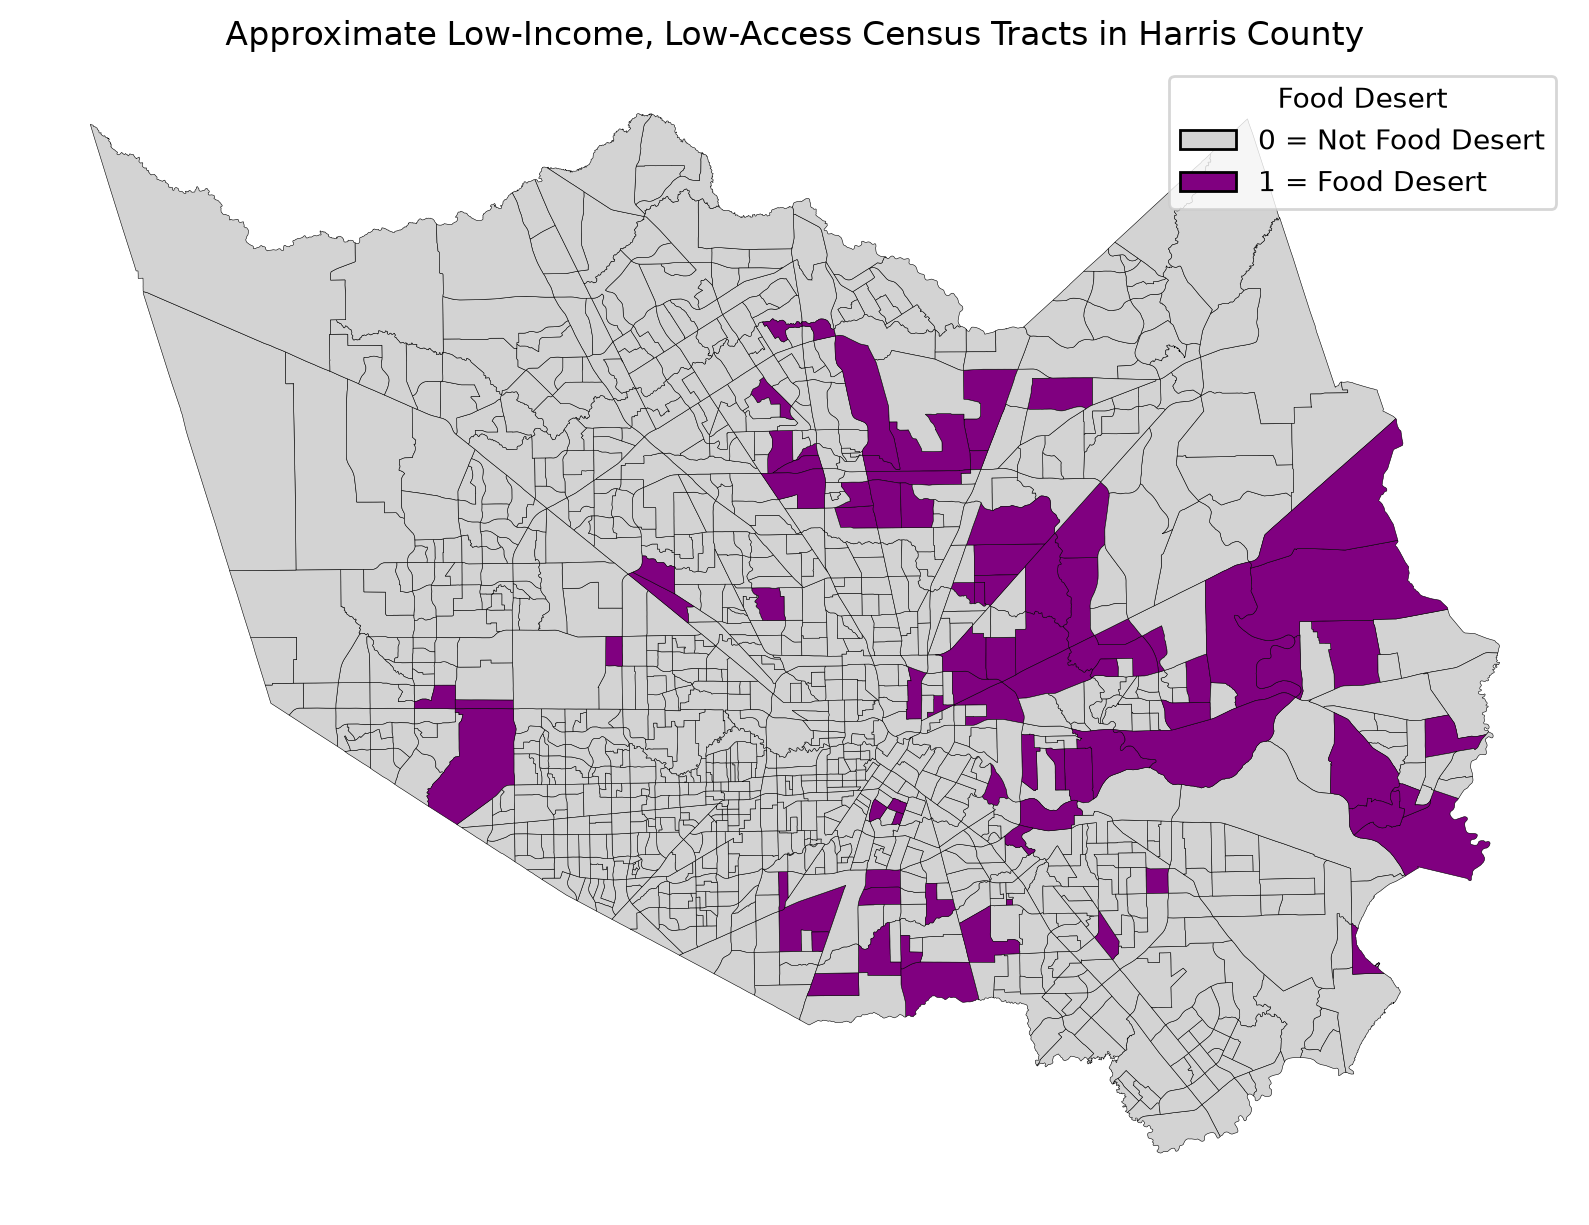

In [55]:
#binary map
fig, ax = plt.subplots(figsize=(10,10))

final_map.plot(
    column = "food_desert",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

#making a legend

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Food Desert"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Food Desert")
]

ax.legend(handles=legend_elements, title="Food Desert")
plt.title("Approximate Low-Income, Low-Access Census Tracts in Harris County")
plt.axis("off")
plt.show()